In [18]:
pip install opencv-python


  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/a4/7d/f1c30a92854540bf789e9cd5dde7ef49bbe63f855b85a2e6b3db8135c591/opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
Note: you may need to restart the kernel to use updated packages.


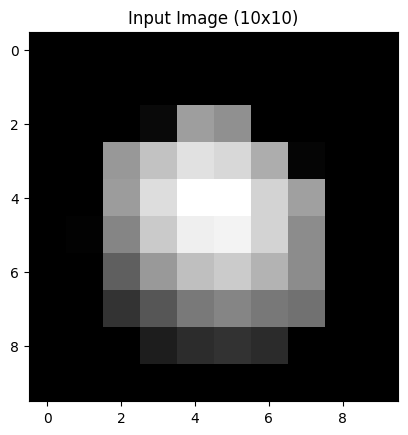

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image_path = r"E:\AHZ\IIT Hyderabad\new dicom.png"

img = cv2.imread(image_path, 0)  
if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")
img_resized = cv2.resize(img, (10, 10), interpolation=cv2.INTER_LANCZOS4)
input_image = img_resized / 255.0  

plt.imshow(input_image, cmap='gray')
plt.title("Input Image (10x10)")
plt.show()


In [34]:

num_filters = int(input("Enter number of filters: "))
stride = int(input("Enter stride value: "))
activation_type = input("Enter activation type (relu/sigmoid): ")
kernel_sizes = [(2, 2), (3, 3), (5, 5)]  


Enter number of filters:  5
Enter stride value:  2
Enter activation type (relu/sigmoid):  relu


In [36]:

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def apply_activation(x, activation_type):
    return relu(x) if activation_type == "relu" else sigmoid(x)


In [38]:
def conv2d(input_image, kernel_size, num_filters, stride):
    h, w = input_image.shape
    kh, kw = kernel_size
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    feature_maps = np.zeros((num_filters, out_h, out_w))
    filters = [np.random.rand(kh, kw) for _ in range(num_filters)]

    for f in range(num_filters):
        for i in range(0, h - kh + 1, stride):
            for j in range(0, w - kw + 1, stride):
                region = input_image[i:i+kh, j:j+kw]
                feature_maps[f, i//stride, j//stride] = np.sum(region * filters[f])
    return feature_maps


In [40]:
def max_pooling(feature_maps, pool_size=(2, 2)):
    num_filters, h, w = feature_maps.shape
    ph, pw = pool_size
    out_h = h // ph
    out_w = w // pw
    pooled = np.zeros((num_filters, out_h, out_w))

    for f in range(num_filters):
        for i in range(out_h):
            for j in range(out_w):
                region = feature_maps[f, i*ph:i*ph+ph, j*pw:j*pw+pw]
                pooled[f, i, j] = np.max(region)
    return pooled


In [42]:

def flatten(feature_maps):
    return feature_maps.reshape(-1)


def dense_layer(input_vector, weights, bias):
    return np.dot(input_vector, weights) + bias


In [44]:

final_outputs = {}

for kernel_size in kernel_sizes:
    
    conv_out = conv2d(input_image, kernel_size, num_filters, stride)
    conv_out = apply_activation(conv_out, activation_type)
    print(conv_out)


    pooled_out = max_pooling(conv_out)
    print("After poling out image ",pooled_out)


    flat = flatten(pooled_out)

    weights1 = np.random.rand(flat.shape[0], 10)
    bias1 = np.random.rand(10)
    dense1 = apply_activation(dense_layer(flat, weights1, bias1), activation_type)


    weights2 = np.random.rand(10, 1)
    bias2 = np.random.rand(1)
    output = dense_layer(dense1, weights2, bias2)

    final_outputs[kernel_size] = output

print("\n=== Final Output for Each Kernel Size ===")
for kernel_size, output in final_outputs.items():
    print(f"Kernel Size {kernel_size}: Output = {output.ravel()[0]:.4f}")


[[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00]
  [0.00000000e+00 4.21943419e-01 1.09299102e+00 3.05275639e-01
   0.00000000e+00]
  [1.35535624e-03 1.16571780e+00 1.54987803e+00 1.10324731e+00
   0.00000000e+00]
  [0.00000000e+00 6.92897038e-01 1.06455573e+00 8.43745627e-01
   0.00000000e+00]
  [0.00000000e+00 9.50156725e-02 1.87579325e-01 2.64068673e-02
   0.00000000e+00]]

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00]
  [0.00000000e+00 6.90908951e-01 1.30706608e+00 1.28148490e-01
   0.00000000e+00]
  [5.90821546e-03 1.47954541e+00 1.80513493e+00 1.14104491e+00
   0.00000000e+00]
  [0.00000000e+00 8.42074837e-01 1.21404686e+00 9.30605818e-01
   0.00000000e+00]
  [0.00000000e+00 1.07277518e-01 1.85516482e-01 4.15552764e-03
   0.00000000e+00]]

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
   0.00000000e+00]
  [0.00000000e+00 5.54363823e-01 1.22924966e+00 4.96691263e-01
   0.00000000e+00]
  [1.2760861